<a href="https://colab.research.google.com/github/Shibam-Shaw/House-price-prediction/blob/main/HOUSE_PRICE_PREDICTION_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import numpy as np
import pandas as pd

##1. Load the Data

In [68]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanbera19/bengaluru-house-price-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bengaluru-house-price-dataset' dataset.
Path to dataset files: /kaggle/input/bengaluru-house-price-dataset


In [69]:
import os

# The 'path' variable from the previous cell contains the directory to the downloaded dataset.
# We found the actual CSV file name from the previous step.
csv_file_name = 'bengaluru_house_prices.csv'
csv_file_path = os.path.join(path, csv_file_name)
df = pd.read_csv(csv_file_path)
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


#2. Quick Data Summary

In [70]:
df.shape

(13320, 9)

In [71]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [72]:
# Checking the total null values of each column
df.isna().sum().sort_values(ascending=False)

,0
society,5502
balcony,609
bath,73
size,16
location,1
area_type,0
availability,0
total_sqft,0
price,0


#3. Clean / Normalize Some Columns

In [73]:
df["bhk"] = df["size"].str.split().str.get(0).astype(float)
df["bhk"]

,bhk
0,2.0
1,4.0
2,3.0
3,3.0
4,2.0
...,...
13315,5.0
13316,4.0
13317,2.0
13318,4.0


In [74]:
def convert_sqft(x):
    if "-" in x:
        a, b = x.split("-")
        return (float(a) + float(b)) / 2
    try:
        return float(x)
    except:
        return None

df["total_sqft"] = df["total_sqft"].apply(convert_sqft)


In [75]:
df["total_sqft"]

,total_sqft
0,1056.0
1,2600.0
2,1440.0
3,1521.0
4,1200.0
...,...
13315,3453.0
13316,3600.0
13317,1141.0
13318,4689.0


#4. Handling Missing Values

In [76]:
df = df.dropna(subset=["total_sqft","bath","bhk","price"])

#5. Feature Exploration

In [77]:
df["location"] = df["location"].str.strip()
loc_counts = df["location"].value_counts()
loc_counts

,count
location,
Whitefield,533
Sarjapur Road,392
Electronic City,304
Kanakpura Road,264
Thanisandra,235
...,...
Zuzuvadi,1
Chellikere,1
Jakkasandra,1


<Axes: ylabel='location'>

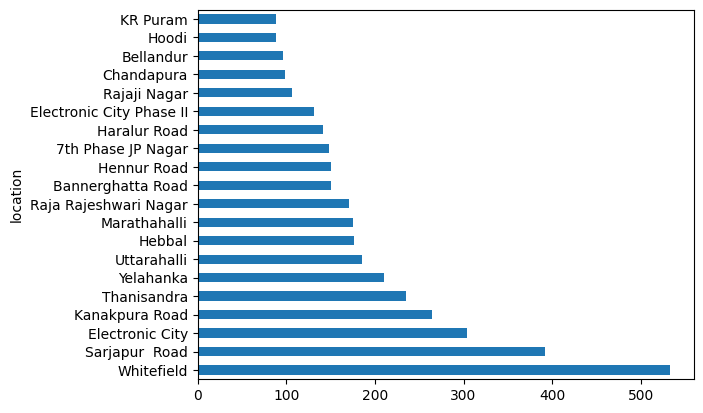

In [78]:
loc_counts[:20].plot(kind="barh")

<Axes: xlabel='total_sqft', ylabel='price'>

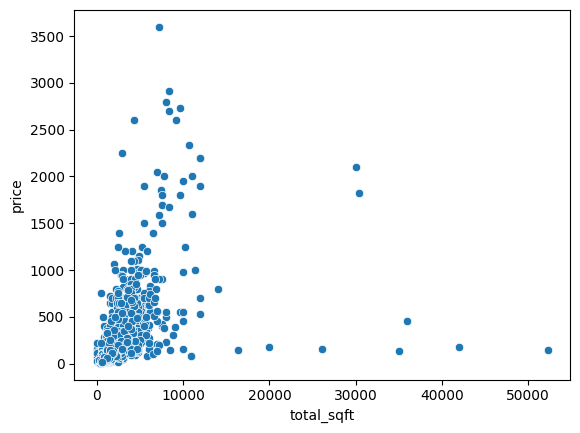

In [79]:
import seaborn as sns
sns.scatterplot(data=df, x="total_sqft", y="price")

<Axes: xlabel='total_sqft', ylabel='price'>

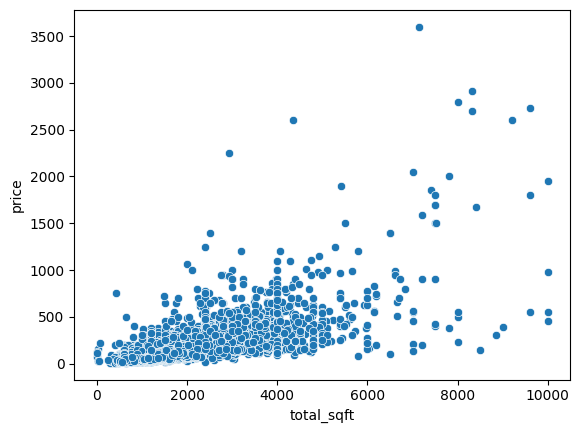

In [80]:
sns.scatterplot(data=df[df["total_sqft"] <= 10000], x="total_sqft", y="price")

<Axes: xlabel='total_sqft', ylabel='price'>

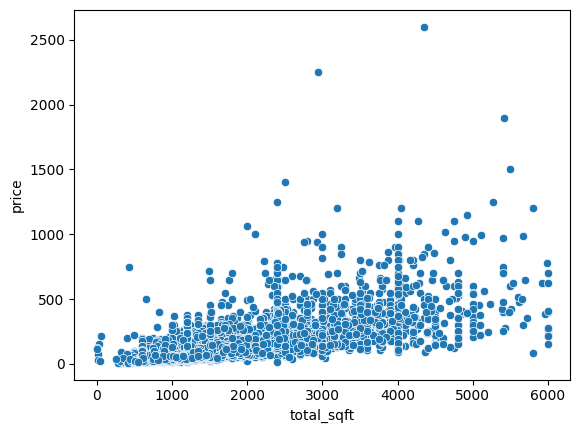

In [81]:
sns.scatterplot(data=df[df["total_sqft"] <= 6000], x="total_sqft", y="price")

<Axes: xlabel='total_sqft', ylabel='price'>

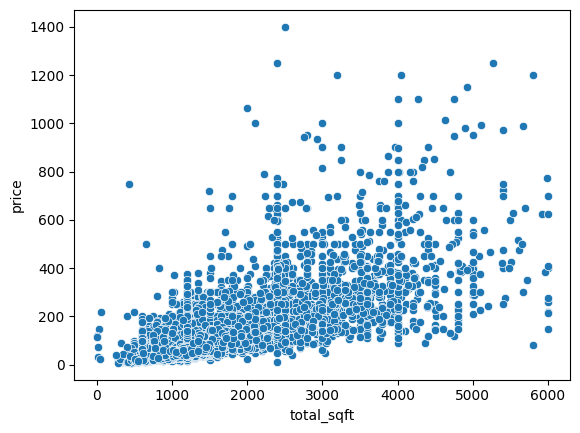

In [82]:
sns.scatterplot(
    data=df[(df["total_sqft"] <= 6000) & (df["price"] < 1500)],
    x="total_sqft",
    y="price"
)

<Axes: xlabel='bhk', ylabel='price'>

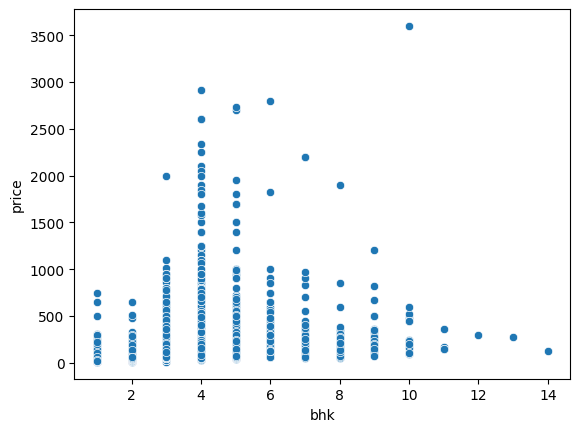

In [83]:
sns.scatterplot(data=df[df["bhk"] <= 15], x="bhk", y="price")

In [84]:
# Price per Square-feet
df["price_per_sqft"] = df["price"] * 100000 / df["total_sqft"]   # price usually in lakhs
df
#sns.histplot(df["price_per_sqft"], bins=50)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2.0,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2.0,4250.000000
...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453.0,4.0,0.0,231.00,5.0,6689.834926
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600.0,5.0,NaN,400.00,4.0,11111.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141.0,2.0,1.0,60.00,2.0,5258.545136
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689.0,4.0,1.0,488.00,4.0,10407.336319


In [85]:

df = df[(df["price_per_sqft"] > 100) & (df["price_per_sqft"] < 10000)]
df = df[df["bath"] < df["bhk"] + 2]

display(df.head())

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2.0,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2.0,4250.000000


<Axes: xlabel='bhk', ylabel='price'>

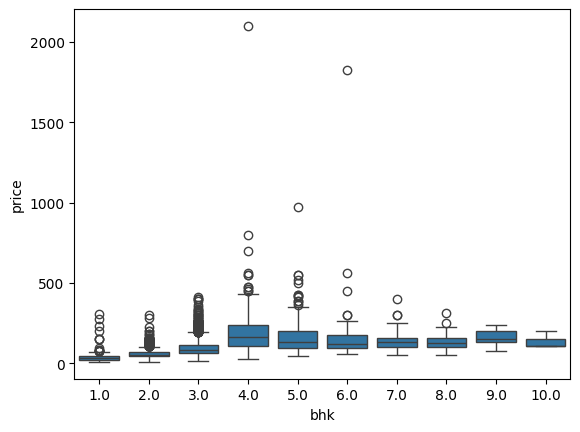

In [86]:
sns.boxplot(
    x="bhk",
    y="price",
    data=df[df["bhk"] <= 10]
)


#6. Correlation and Heatmap

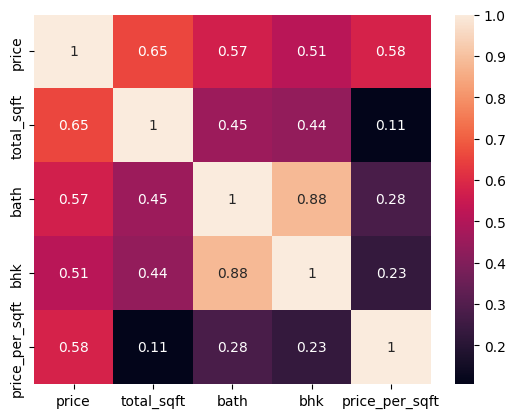

In [87]:
# Shows which numeric variables are most tied to price

import matplotlib.pyplot as plt
num_df = df[["price","total_sqft","bath","bhk","price_per_sqft"]]
sns.heatmap(num_df.corr(), annot=True)
plt.show()

#7. Outlier Detection

In [88]:
df = df[(df["price_per_sqft"]>100) & (df["price_per_sqft"]<10000)]
df = df[df["bath"] < df["bhk"]+2]
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2.0,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2.0,4250.000000
...,...,...,...,...,...,...,...,...,...,...,...
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345.0,2.0,1.0,57.00,3.0,4237.918216
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715.0,3.0,3.0,112.00,3.0,6530.612245
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453.0,4.0,0.0,231.00,5.0,6689.834926
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141.0,2.0,1.0,60.00,2.0,5258.545136


#8. Visualization Ideas

<Axes: ylabel='location'>

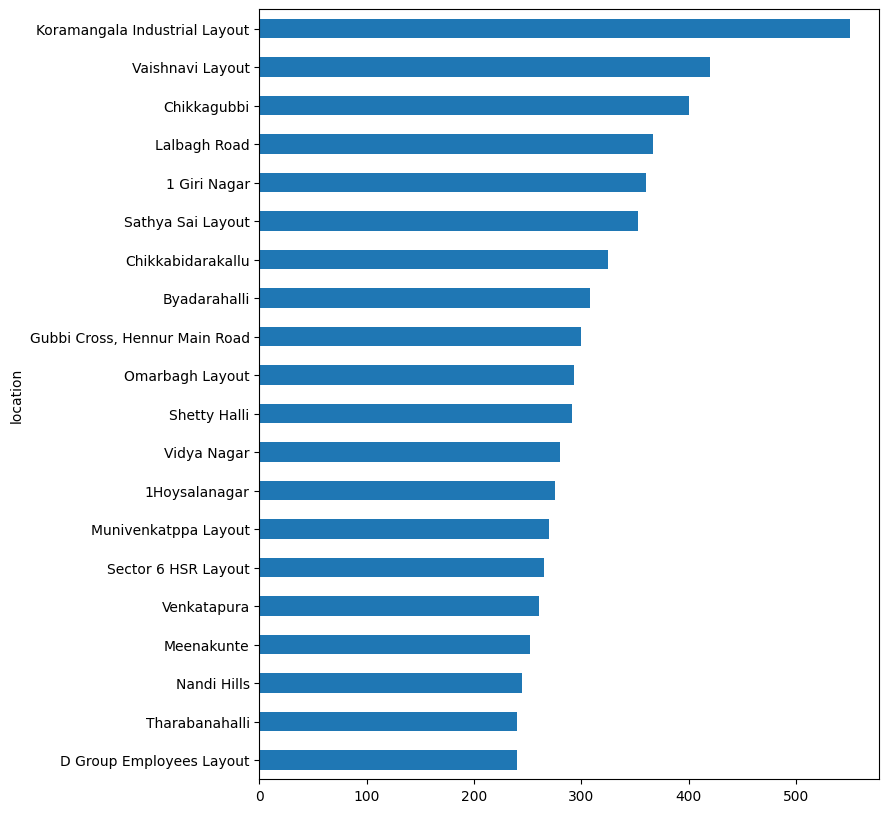

In [89]:
# Bar plot of average price by location:
avg_price_loc = df.groupby("location")["price"].median().sort_values()
avg_price_loc.tail(20).plot(kind="barh", figsize=(8,10))

<Axes: >

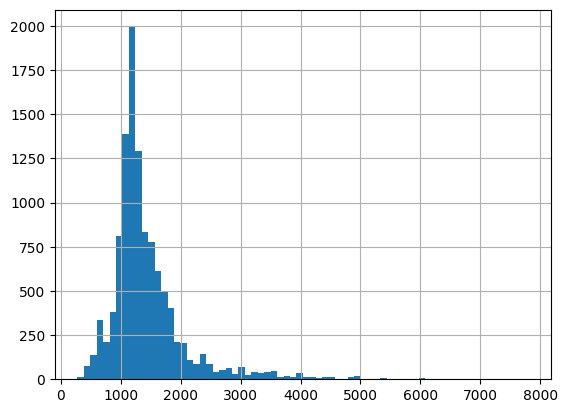

In [90]:
#
df[df["total_sqft"] < 8000]["total_sqft"].hist(bins=70)


# Now EDA is done and let us start the model training, testing part...

In [91]:
X = df.drop("price", axis=1)
y = df["price"]

In [92]:
X = df.drop("price", axis=1)
X = X.drop(["size", "society", "balcony"], axis=1) # Drop original 'size' (represented by 'bhk'), 'society' (many NaNs), and 'balcony' (many NaNs)
X = pd.get_dummies(X, columns=["location", "area_type", "availability"], drop_first=True)
X

,total_sqft,bath,bhk,price_per_sqft,location_1 Immadihalli,location_1Hoysalanagar,location_1st Block BEL Layout,location_1st Block HBR Layout,location_1st Block HRBR Layout,location_1st Block Jayanagar,...,availability_21-Nov,availability_21-Oct,availability_21-Sep,availability_22-Dec,availability_22-Jan,availability_22-Jun,availability_22-Mar,availability_22-May,availability_22-Nov,availability_Ready To Move
0,1056.0,2.0,2.0,3699.810606,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,4.0,4615.384615,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1440.0,2.0,3.0,4305.555556,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1521.0,3.0,3.0,6245.890861,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1200.0,2.0,2.0,4250.000000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13313,1345.0,2.0,3.0,4237.918216,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
13314,1715.0,3.0,3.0,6530.612245,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
13315,3453.0,4.0,5.0,6689.834926,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
13317,1141.0,2.0,2.0,5258.545136,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [97]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [98]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = lr.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7310673174390332
MAE: 14.487301814660045
RMSE: 35.12663870535703


Linear Regression has done it's job well but from the visualizations it is quiet clear that Bangaluru House Prices are non-linear so now let us try Random Forest and see if they can reduce the loss further and improve the accuracy.

In [99]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("R2:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))


R2: 0.9502109225150104
MAE: 0.8727855024347065
RMSE: 15.114084349835762


In [100]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)


,0
total_sqft,0.694443
price_per_sqft,0.237071
location_Dodsworth Layout,0.052853
bhk,0.005227
bath,0.003712
location_Ulsoor,0.001588
location_Bannerghatta Road,0.001023
location_Sarjapur Road,0.000882
area_type_Super built-up Area,0.000564
area_type_Plot Area,0.000561


In [104]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='r2', verbose=2)

In [106]:
best_rf = rf_search.best_estimator_

best_pred = best_rf.predict(X_test)

print("Best R2:", r2_score(y_test, best_pred))
print("Best MAE:", mean_absolute_error(y_test, best_pred))
print("Best RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))


Best R2: 0.7458599370371037
Best MAE: 7.819805415679172
Best RMSE: 34.14690674103789


In [107]:
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

rf.fit(X_train, y_train)

pred_log = rf.predict(X_test)
pred = np.expm1(pred_log)

print("R2:", r2_score(np.expm1(y_test), pred))
print("MAE:", mean_absolute_error(np.expm1(y_test), pred))


R2: 0.9400788713930056
MAE: 0.9335855294181685


In [108]:
import joblib

joblib.dump(best_rf, "model.pkl")
joblib.dump(X_train.columns, "columns.pkl")

['columns.pkl']

In [110]:
print(X_train.columns.tolist())


['total_sqft', 'bath', 'bhk', 'price_per_sqft', 'location_1 Immadihalli', 'location_1Hoysalanagar', 'location_1st Block BEL Layout', 'location_1st Block HBR Layout', 'location_1st Block HRBR Layout', 'location_1st Block Jayanagar', 'location_1st Block Koramangala', 'location_1st Phase JP Nagar', 'location_1st Stage Domlur', 'location_1st Stage Indira Nagar', 'location_2Electronic City Phase II', 'location_2nd Block Bel Layout', 'location_2nd Block Hbr Layout', 'location_2nd Block Hrbr Layout', 'location_2nd Block Jayanagar', 'location_2nd Phase JP Nagar', 'location_2nd Phase Judicial Layout', 'location_2nd Stage Arekere Mico Layout', 'location_2nd Stage Nagarbhavi', 'location_3rd Block Banashankari', 'location_3rd Block HBR Layout', 'location_3rd Block Hrbr Layout', 'location_3rd Block Koramangala', 'location_3rd Phase Iti Layout', 'location_3rd Phase JP Nagar', 'location_3rd Stage Raja Rajeshwari Nagar', 'location_4 Bedroom Farm House in Bagalur', 'location_4th Block Jayanagar', 'loca